## Cell 1 — Import Libraries & Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

for dirname, _, filenames in os.walk('/kaggle/input/datasets/sneharakshit511/zomato1'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sneharakshit511/zomato1/test_zomato.csv


## Cell 2 — Read the CSV

In [2]:
path = None
for dirname, _, filenames in os.walk('/kaggle/input/datasets/sneharakshit511/zomato1'):
    for filename in filenames:
        if filename.lower().endswith(('.csv', '.xlsx')):
            path = os.path.join(dirname, filename)
            break

print(path)

if path.lower().endswith('.csv'):
    df = pd.read_csv(path, encoding='latin-1')
else:
    df = pd.read_excel(path)

df.head()

/kaggle/input/datasets/sneharakshit511/zomato1/test_zomato.csv


,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


## Cell 3 — Add Missing ID Column

In [3]:
unnamed = [c for c in df.columns if str(c).startswith('Unnamed')]

if unnamed:
    df = df.rename(columns={unnamed[0]: 'ID'})
else:
    df.insert(0, 'ID', np.arange(len(df)))

df.columns = df.columns.str.strip()
df.head()

,ID,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


## Cell 4 — Dataset Shape, Columns & Data Types

In [4]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
print("Column Names:")
print(list(df.columns))
print()
df.info()

Shape: (9552, 22)
Rows: 9552
Columns: 22

Column Names:
['ID', 'Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9552 entries, 0 to 9551
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    9552 non-null   object 
 1   Restaurant ID         9552 non-null   object 
 2   Restaurant Name       9552 non-null   object 
 3   Country Code          9552 non-null   float64
 4   City                  9552 non-null   object 
 5   Address               9552 non-null   object 
 6   Locality              9551 non-null   object 
 7   Locality Verbose      955

## Cell 5 — Missing Value Analysis

In [5]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing if len(missing) else "No missing values found")

                      Missing Count  Missing %
Cuisines                         10       0.10
Rating color                      2       0.02
Rating text                       2       0.02
Votes                             2       0.02
Aggregate rating                  2       0.02
Price range                       2       0.02
Longitude                         1       0.01
Locality                          1       0.01
Has Table booking                 1       0.01
Currency                          1       0.01
Average Cost for two              1       0.01
Latitude                          1       0.01
Locality Verbose                  1       0.01
Switch to order menu              1       0.01
Has Online delivery               1       0.01
Is delivering now                 1       0.01


## Cell 6 — Duplicate Records

In [6]:
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate Restaurant IDs:", df['Restaurant ID'].duplicated().sum())

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Full duplicate rows: 0
Duplicate Restaurant IDs: 0
Shape after removing duplicates: (9552, 22)


## Cell 7 — Data Cleaning & Type Conversion

In [7]:
df['Average Cost for two'] = (
    df['Average Cost for two']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Average Cost for two'] = pd.to_numeric(df['Average Cost for two'], errors='coerce')

df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'], errors='coerce')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Price range'] = pd.to_numeric(df['Price range'], errors='coerce')

df['Cuisines'] = df['Cuisines'].fillna('Not Specified')
df['City'] = df['City'].str.strip()

df[['Average Cost for two', 'Aggregate rating', 'Votes', 'Price range']].dtypes

Average Cost for two    float64
Aggregate rating        float64
Votes                   float64
Price range             float64
dtype: object

## Cell 8 — Statistical Summary

In [8]:
display(df.describe())
display(df.describe(include='object'))

,Country Code,Average Cost for two,Price range,Aggregate rating,Votes
count,9552.000000,9550.000000,9550.000000,9550.000000,9550.000000
mean,18.374564,1199.326387,1.804607,2.666314,156.923037
std,56.754313,16122.023220,0.905378,1.516447,430.189709
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,250.000000,1.000000,2.500000,5.000000
50%,1.000000,400.000000,2.000000,3.200000,31.000000
75%,1.000000,700.000000,2.000000,3.700000,131.000000
max,216.000000,800000.000000,4.000000,4.900000,10934.000000


,ID,Restaurant ID,Restaurant Name,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Rating color,Rating text
count,9552,9552,9552,9552,9552,9551,9551,9551,9551,9552,9551,9551,9551,9551,9551,9550,9550
unique,9552,9552,7447,142,8919,1208,1265,8120,8677,1827,13,3,3,3,2,6,6
top,9534,6004089,Cafe Coffee Day,New Delhi,"Dilli Haat, INA, New Delhi",Connaught Place,"Connaught Place, New Delhi",0.0,0.0,North Indian,Indian Rupees(Rs.),No,No,No,No,Orange,Average
freq,1,1,83,5473,11,122,122,498,498,936,8652,8392,7099,9516,9550,3736,3736


## Cell 9 — Unique Cities, Top City, Top Cuisine

In [9]:
print("Unique cities:", df['City'].nunique())
print()

print("City with highest number of restaurants:")
print(df['City'].value_counts().head(1))
print()

cuisine_counts = (
    df['Cuisines'].str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)
print("Most frequent cuisine:")
print(cuisine_counts.head(1))

Unique cities: 142

City with highest number of restaurants:
City
New Delhi    5473
Name: count, dtype: int64

Most frequent cuisine:
Cuisines
North Indian    3960
Name: count, dtype: int64


## Cell 10 — Part 2: Core Metrics

In [10]:
print("Average restaurant rating (all):", round(df['Aggregate rating'].mean(), 2))
print("Average rating (excluding unrated):", round(df[df['Aggregate rating'] > 0]['Aggregate rating'].mean(), 2))
print("Average cost for two:", round(df['Average Cost for two'].mean(), 2))
print("Median cost for two:", df['Average Cost for two'].median())

Average restaurant rating (all): 2.67
Average rating (excluding unrated): 3.44
Average cost for two: 1199.33
Median cost for two: 400.0


## Cell 11 — Restaurant with Highest Votes

In [11]:
top_voted = df.loc[df['Votes'].idxmax()]
print(top_voted[['Restaurant Name', 'City', 'Cuisines', 'Votes', 'Aggregate rating']])
print()
display(df.nlargest(10, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating']])

Restaurant Name                         Toit
City                               Bangalore
Cuisines            Italian, American, Pizza
Votes                                10934.0
Aggregate rating                         4.8
Name: 729, dtype: object



,Restaurant Name,City,Votes,Aggregate rating
729,Toit,Bangalore,10934.0,4.8
736,Truffles,Bangalore,9667.0,4.7
3995,Hauz Khas Social,New Delhi,7931.0,4.3
2413,Peter Cat,Kolkata,7574.0,4.3
740,AB's - Absolute Barbecues,Bangalore,6907.0,4.6
2415,Barbeque Nation,Kolkata,5966.0,4.9
744,Big Brewsky,Bangalore,5705.0,4.5
2308,AB's - Absolute Barbecues,Hyderabad,5434.0,4.9
737,The Black Pearl,Bangalore,5385.0,4.1
2412,BarBQ,Kolkata,5288.0,4.2


## Cell 12 — Online Delivery vs Rating

In [12]:
online = df.groupby('Has Online delivery')['Aggregate rating'].agg(['mean', 'count']).round(2)
display(online)

online_nz = df[df['Aggregate rating'] > 0].groupby('Has Online delivery')['Aggregate rating'].mean().round(2)
print("\nExcluding unrated restaurants:")
print(online_nz)

,mean,count
Has Online delivery,,
No,2.47,7099
Orange,NaN,0
Yes,3.25,2451



Excluding unrated restaurants:
Has Online delivery
No     3.47
Yes    3.38
Name: Aggregate rating, dtype: float64


## Cell 13 — Table Booking vs Rating

In [13]:
booking = df.groupby('Has Table booking')['Aggregate rating'].agg(['mean', 'count']).round(2)
display(booking)

booking_nz = df[df['Aggregate rating'] > 0].groupby('Has Table booking')['Aggregate rating'].mean().round(2)
print("\nExcluding unrated restaurants:")
print(booking_nz)

,mean,count
Has Table booking,,
3.2,NaN,0
No,2.56,8392
Yes,3.44,1158



Excluding unrated restaurants:
Has Table booking
No     3.41
Yes    3.59
Name: Aggregate rating, dtype: float64


## Cell 14 — Top 10 Cities by Restaurant Count

In [14]:
top_cities = df['City'].value_counts().head(10)
display(top_cities)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

## Cell 15 — Visualization 1: Top 10 Cities (Bar Chart)

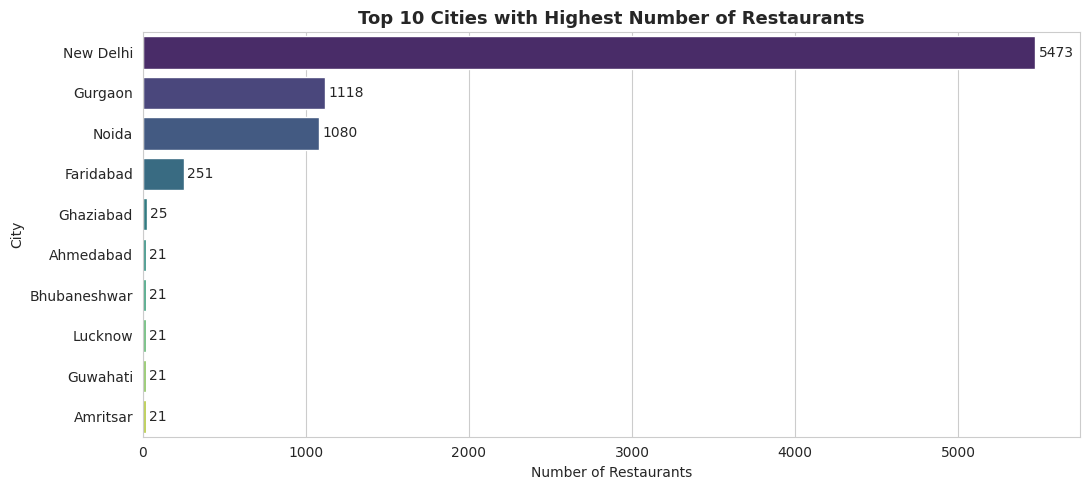

In [15]:
plt.figure(figsize=(11, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities with Highest Number of Restaurants', fontsize=13, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
for i, v in enumerate(top_cities.values):
    plt.text(v + 20, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Cell 16 — Visualization 2: Distribution of Ratings (Histogram)

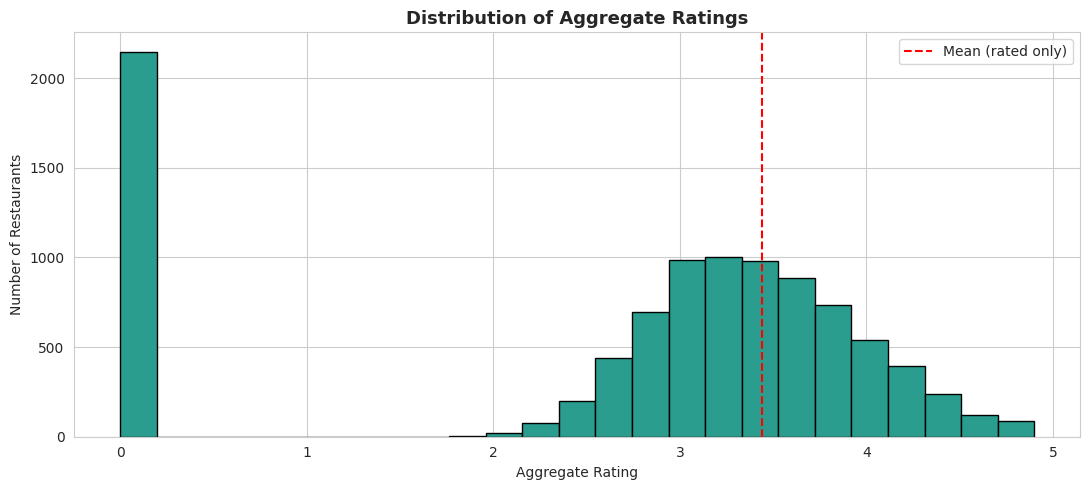

In [16]:
plt.figure(figsize=(11, 5))
plt.hist(df['Aggregate rating'], bins=25, color='#2a9d8f', edgecolor='black')
plt.axvline(df[df['Aggregate rating'] > 0]['Aggregate rating'].mean(), color='red',
            linestyle='--', label='Mean (rated only)')
plt.title('Distribution of Aggregate Ratings', fontsize=13, fontweight='bold')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.legend()
plt.tight_layout()
plt.show()

## Cell 17 — Visualization 3: Online Delivery Availability (Bar Chart)

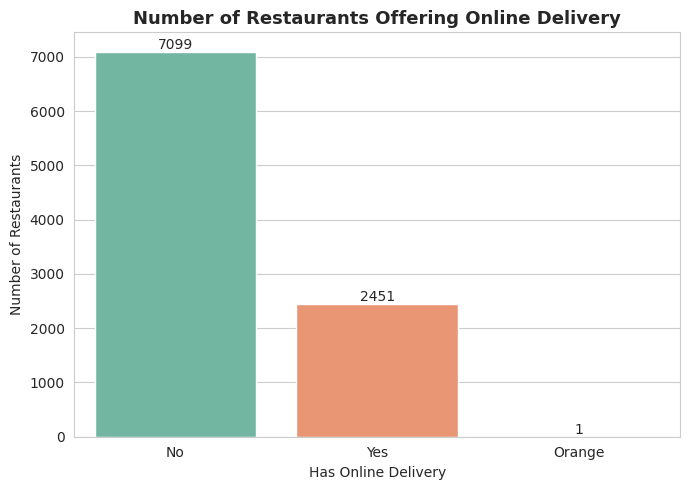

In [17]:
delivery_counts = df['Has Online delivery'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=delivery_counts.index, y=delivery_counts.values, palette='Set2')
plt.title('Number of Restaurants Offering Online Delivery', fontsize=13, fontweight='bold')
plt.xlabel('Has Online Delivery')
plt.ylabel('Number of Restaurants')
for i, v in enumerate(delivery_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

## Cell 18 — Visualization 4: Top 10 Cuisines (Bar Chart)

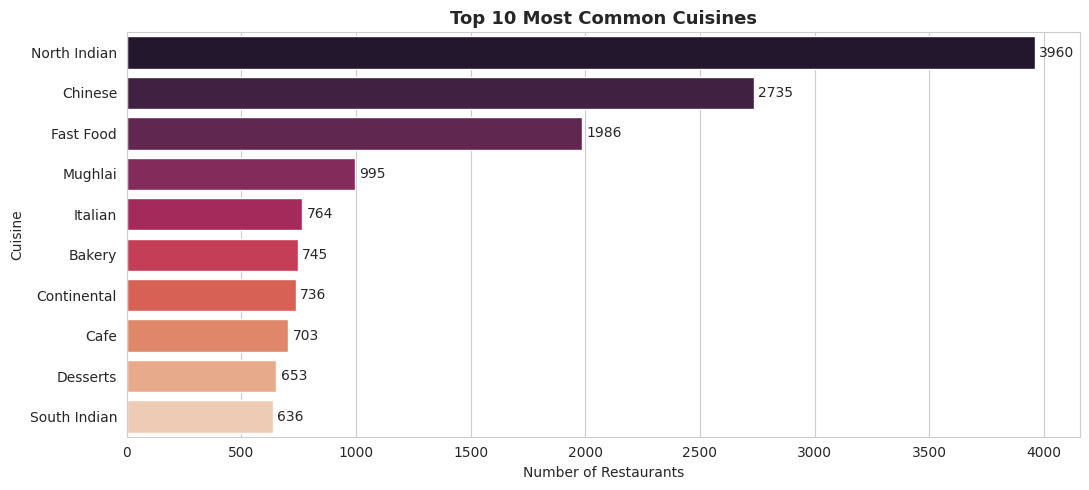

In [18]:
top_cuisines = cuisine_counts.head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='rocket')
plt.title('Top 10 Most Common Cuisines', fontsize=13, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
for i, v in enumerate(top_cuisines.values):
    plt.text(v + 20, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Cell 19 — Visualization 5: Average Rating by Price Range (Line Chart)

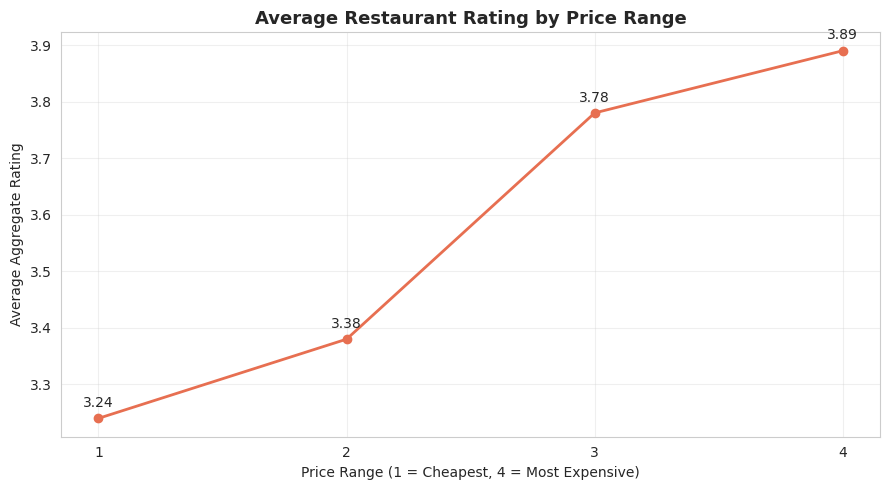

Price range
1.0    3.24
2.0    3.38
3.0    3.78
4.0    3.89
Name: Aggregate rating, dtype: float64


In [19]:
price_rating = df[df['Aggregate rating'] > 0].groupby('Price range')['Aggregate rating'].mean().round(2)

plt.figure(figsize=(9, 5))
plt.plot(price_rating.index, price_rating.values, marker='o', linewidth=2, color='#e76f51')
plt.title('Average Restaurant Rating by Price Range', fontsize=13, fontweight='bold')
plt.xlabel('Price Range (1 = Cheapest, 4 = Most Expensive)')
plt.ylabel('Average Aggregate Rating')
plt.xticks([1, 2, 3, 4])
for x, y in zip(price_rating.index, price_rating.values):
    plt.text(x, y + 0.02, str(y), ha='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(price_rating)

## Cell 20 — Extra: Correlation Heatmap

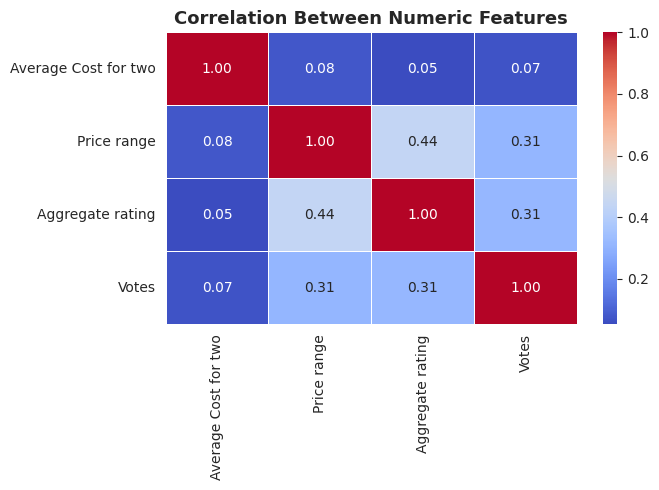

In [20]:
num_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 21 — Part 4: Insights & Conclusion

In [21]:
print("=" * 55)
print("FINAL INSIGHTS")
print("=" * 55)

print("1. City with highest restaurant presence :", df['City'].value_counts().idxmax(),
      "(", df['City'].value_counts().max(), "restaurants )")

print("2. Most popular cuisine                  :", cuisine_counts.idxmax(),
      "(", cuisine_counts.max(), "restaurants )")

d = df[df['Aggregate rating'] > 0].groupby('Has Online delivery')['Aggregate rating'].mean().round(2)
print("3. Online delivery ratings   -> Yes:", d.get('Yes'), "| No:", d.get('No'))

b = df[df['Aggregate rating'] > 0].groupby('Has Table booking')['Aggregate rating'].mean().round(2)
print("4. Table booking ratings     -> Yes:", b.get('Yes'), "| No:", b.get('No'))

print("5. Overall average rating (rated only)   :",
      round(df[df['Aggregate rating'] > 0]['Aggregate rating'].mean(), 2))
print("6. Average cost for two                  :",
      round(df['Average Cost for two'].mean(), 2))
print("=" * 55)

FINAL INSIGHTS
1. City with highest restaurant presence : New Delhi ( 5473 restaurants )
2. Most popular cuisine                  : North Indian ( 3960 restaurants )
3. Online delivery ratings   -> Yes: 3.38 | No: 3.47
4. Table booking ratings     -> Yes: 3.59 | No: 3.41
5. Overall average rating (rated only)   : 3.44
6. Average cost for two                  : 1199.33


### Conclusion

**1. Highest restaurant presence:** New Delhi dominates with 5,473 restaurants, followed by Gurgaon (1,118) and Noida (1,080). Delhi-NCR alone accounts for roughly 8,000 of the listings. Beyond Faridabad (251), every remaining city caps out at about 21 restaurants each, which points to a sampling limit rather than genuine market size — so city counts outside NCR should not be read as true restaurant density.

**2. Most popular cuisine:** North Indian is the most frequently listed cuisine, appearing in 3,960 restaurant listings. Since restaurants list multiple cuisines, this count reflects combinations rather than exclusive North Indian outlets, and its dominance is a direct consequence of the NCR concentration above.

**3. Online delivery vs ratings:** Restaurants offering online delivery average **3.38**, slightly *below* the 3.47 of those without. The intuitive expectation that delivery drives better ratings does not hold here. A likely explanation is composition: delivery is concentrated among budget and fast-food outlets in price ranges 1–2, which rate lower overall, while many premium dine-in restaurants skip delivery entirely. The 0.09 gap is also small enough that it carries little practical weight on its own.

**4. Table booking vs ratings:** Restaurants with table booking average **3.59** versus **3.41** without — a clear positive gap. Table booking is typically offered by premium, service-oriented establishments, so this aligns with the price-range trend rather than proving that booking itself causes satisfaction.

**5. Price range is the strongest signal:** Average rating climbs steadily with price — 3.24, 3.38, 3.78, 3.89 across ranges 1 to 4. This monotonic rise of 0.65 points is the most consistent relationship in the dataset and plausibly explains both the table-booking gap and the online-delivery reversal, since both features cluster at opposite ends of the price scale.

**6. Overall figures:** Average rating across rated restaurants is **3.44**, and the average cost for two is **₹1,199**.

**7. Key learnings:** Real-world data needs careful cleaning — the 0 ratings represent unrated restaurants, not bad ones, and including them drags every average downward. More importantly, this dataset shows that a feature's association with ratings can reverse once you consider what kind of restaurant offers it; price segment, not the feature itself, appears to be the underlying driver. Because the data is heavily skewed toward Delhi-NCR, these insights generalise to Indian metro markets but not globally.